<a href="https://colab.research.google.com/github/ParhamPishro/Flavonoid/blob/main/6%20Importance%20of%20Features/Correlation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm


Read Data

In [2]:
df = pd.read_excel("/content/FlavonoidData.xlsx")
df

,authors,flavonoid,cell line,time,dose,viability-mean,viability-error,viability-SD,viability-SE
0,Chen et al. 2017,Luteolin,KYSE30,48,10.0,77.272727,77.272727,0.001000,NaN
1,Chen et al. 2017,Luteolin,KYSE30,48,20.0,67.613636,67.613636,0.001000,NaN
2,Chen et al. 2017,Luteolin,KYSE30,48,40.0,47.159091,47.159091,0.001000,NaN
3,Chen et al. 2017,Luteolin,KYSE30,48,80.0,32.386364,32.386364,0.001000,NaN
4,Chen et al. 2017,Luteolin,KYSE30,72,10.0,69.886364,69.886364,0.001000,NaN
...,...,...,...,...,...,...,...,...,...
479,Zhu et al. 2016,Apigenin,KYSE150,24,20.0,88.407643,88.407643,0.001000,NaN
480,Zhu et al. 2016,Apigenin,KYSE150,24,40.0,78.980892,82.802548,3.821656,NaN
481,Zhu et al. 2016,Apigenin,KYSE150,24,60.0,67.261146,70.828025,3.566879,NaN
482,Zhu et al. 2016,Apigenin,KYSE150,24,80.0,45.350318,47.643312,2.292994,NaN


Discretized Data

In [3]:
df['v01'] = 1
df.loc[df['viability-mean']>50, 'v01'] = 0

In [4]:
df = df.drop(['authors', 'viability-error', 'viability-SD', 'viability-SE'], axis=1)
df

,flavonoid,cell line,time,dose,viability-mean,v01
0,Luteolin,KYSE30,48,10.0,77.272727,0
1,Luteolin,KYSE30,48,20.0,67.613636,0
2,Luteolin,KYSE30,48,40.0,47.159091,1
3,Luteolin,KYSE30,48,80.0,32.386364,1
4,Luteolin,KYSE30,72,10.0,69.886364,0
...,...,...,...,...,...,...
479,Apigenin,KYSE150,24,20.0,88.407643,0
480,Apigenin,KYSE150,24,40.0,78.980892,0
481,Apigenin,KYSE150,24,60.0,67.261146,0
482,Apigenin,KYSE150,24,80.0,45.350318,1


Encoding

In [5]:
df_encoded = pd.get_dummies(df, dtype=int)
df_encoded

,time,dose,viability-mean,v01,flavonoid_Acacetin,flavonoid_Apigenin,flavonoid_Chrysin,flavonoid_Galangin,flavonoid_Kaempferol,flavonoid_Luteolin,flavonoid_Myricetin,flavonoid_Quercetin,cell line_KYSE150,cell line_KYSE30,cell line_KYSE410,cell line_KYSE450,cell line_KYSE510,cell line_OE19,cell line_OE33,cell line_TE-1,cell line_TE-10,cell line_YES2
0,48,10.0,77.272727,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
1,48,20.0,67.613636,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
2,48,40.0,47.159091,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
3,48,80.0,32.386364,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
4,72,10.0,69.886364,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,24,20.0,88.407643,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
480,24,40.0,78.980892,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
481,24,60.0,67.261146,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
482,24,80.0,45.350318,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0


In [6]:
X = df_encoded.drop(['viability-mean', 'v01'], axis=1)
y = df['viability-mean']
y01 = df['v01']

Correlation

<Axes: >

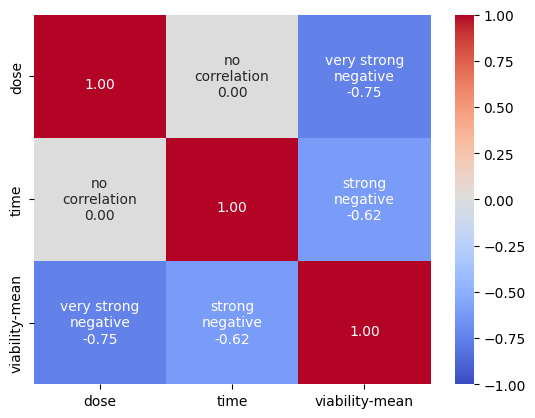

In [24]:
matrix11 = df.loc[df['flavonoid']=='Acacetin', ['dose', 'time', 'viability-mean']].corr()

text11 = np.array([['', 'no\ncorrelation', 'very strong\nnegative'],
 ['no\ncorrelation', '', 'strong\nnegative'],
 ['very strong\nnegative', 'strong\nnegative', '']])

matrix11_arr = np.array(matrix11)

formatted_text11 = (np.asarray(["{0}\n{1:.2f}".format(text11, matrix11) for text11, matrix11
                                in zip(text11.flatten(), matrix11_arr.flatten())])).reshape(3, 3)

sns.heatmap(matrix11, annot=formatted_text11, fmt="", vmin=-1, vmax=1, cmap="coolwarm")

<Axes: >

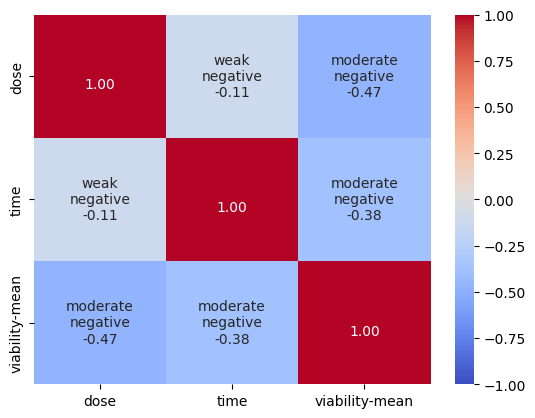

In [25]:
matrix12 = df.loc[df['flavonoid']=='Apigenin', ['dose', 'time', 'viability-mean']].corr()

text12 = np.array([['', 'weak\nnegative', 'moderate\nnegative'],
 ['weak\nnegative', '', 'moderate\nnegative'],
 ['moderate\nnegative', 'moderate\nnegative', '']])

matrix12_arr = np.array(matrix12)

formatted_text12 = (np.asarray(["{0}\n{1:.2f}".format(text12, matrix12) for text12, matrix12
                                in zip(text12.flatten(), matrix12_arr.flatten())])).reshape(3, 3)

sns.heatmap(matrix12, annot=formatted_text12, fmt="", vmin=-1, vmax=1, cmap="coolwarm")

<Axes: >

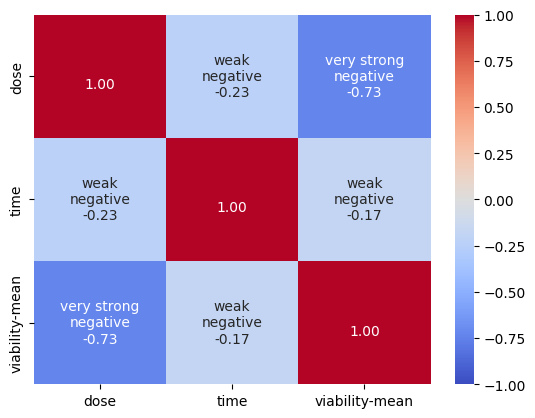

In [26]:
matrix13 = df.loc[df['flavonoid']=='Chrysin', ['dose', 'time', 'viability-mean']].corr()

text13 = np.array([['', 'weak\nnegative', 'very strong\nnegative'],
 ['weak\nnegative', '', 'weak\nnegative'],
 ['very strong\nnegative', 'weak\nnegative', '']])

matrix13_arr = np.array(matrix13)

formatted_text13 = (np.asarray(["{0}\n{1:.2f}".format(text13, matrix13) for text13, matrix13
                                in zip(text13.flatten(), matrix13_arr.flatten())])).reshape(3, 3)

sns.heatmap(matrix13, annot=formatted_text13, fmt="", vmin=-1, vmax=1, cmap="coolwarm")

<Axes: >

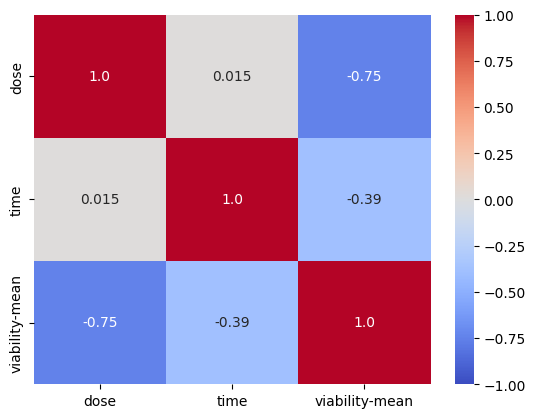

In [27]:
matrix21 = df.loc[df['flavonoid']=='Galangin', ['dose', 'time', 'viability-mean']].corr()

text21 = np.array([['', 'weak\npositive', 'very strong\nnegative'],
 ['weak\npositive', '', 'moderate\nnegative'],
 ['very strong\nnegative', 'moderate\nnegative', '']])

sns.heatmap(matrix21, annot=True, fmt=".2", vmin=-1, vmax=1, cmap="coolwarm")

<Axes: >

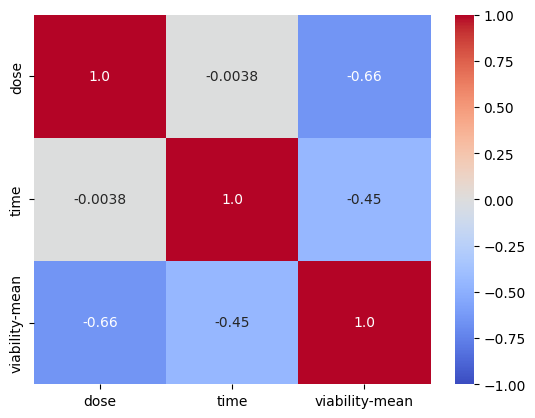

In [28]:
matrix22 = df.loc[df['flavonoid']=='Kaempferol', ['dose', 'time', 'viability-mean']].corr()

text22 = np.array([['', 'no\ncorrelation', 'strong\nnegative'],
 ['no\ncorrelation', '', 'moderate\nnegative'],
 ['strong\nnegative', 'moderate\nnegative', '']])

sns.heatmap(matrix22, annot=True, fmt=".2", vmin=-1, vmax=1, cmap="coolwarm")

<Axes: >

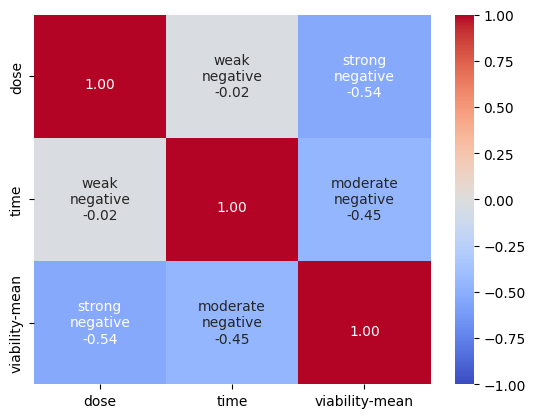

In [29]:
matrix23 = df.loc[df['flavonoid']=='Luteolin', ['dose', 'time', 'viability-mean']].corr()

text23 = np.array([['', 'weak\nnegative', 'strong\nnegative'],
 ['weak\nnegative', '', 'moderate\nnegative'],
 ['strong\nnegative', 'moderate\nnegative', '']])

matrix23_arr = np.array(matrix23)

formatted_text23 = (np.asarray(["{0}\n{1:.2f}".format(text23, matrix23) for text23, matrix23
                                in zip(text23.flatten(), matrix23_arr.flatten())])).reshape(3, 3)

sns.heatmap(matrix23, annot=formatted_text23, fmt="", vmin=-1, vmax=1, cmap="coolwarm")

<Axes: >

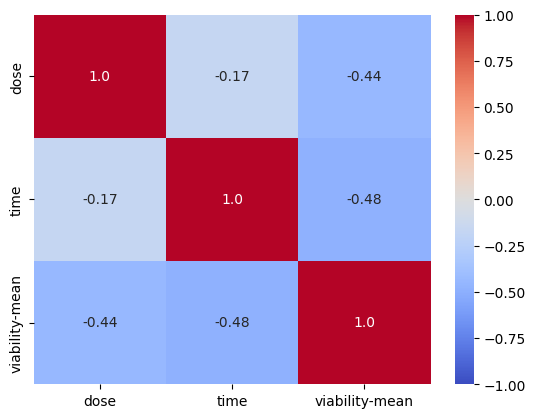

In [30]:
matrix31 = df.loc[df['flavonoid']=='Myricetin', ['dose', 'time', 'viability-mean']].corr()

text31 = np.array([['', 'weak\nnegative', 'moderate\nnegative'],
 ['weak\nnegative', '', 'moderate\nnegative'],
 ['moderate\nnegative', 'moderate\nnegative', '']])

sns.heatmap(matrix31, annot=True, fmt=".2", vmin=-1, vmax=1, cmap="coolwarm")

<Axes: >

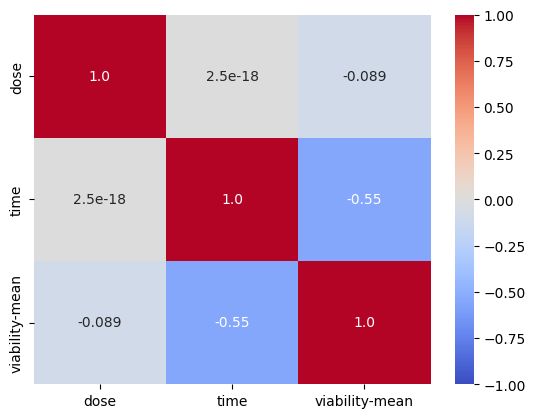

In [31]:
matrix32 = df.loc[df['flavonoid']=='Quercetin', ['dose', 'time', 'viability-mean']].corr()

text32 = np.array([['', 'no\ncorrelation', 'weak\nnegative'],
 ['no\ncorrelation', '', 'strong\nnegative'],
 ['weak\nnegative', 'strong\nnegative', '']])

sns.heatmap(matrix32, annot=True, fmt=".2", vmin=-1, vmax=1, cmap="coolwarm")

<Axes: >

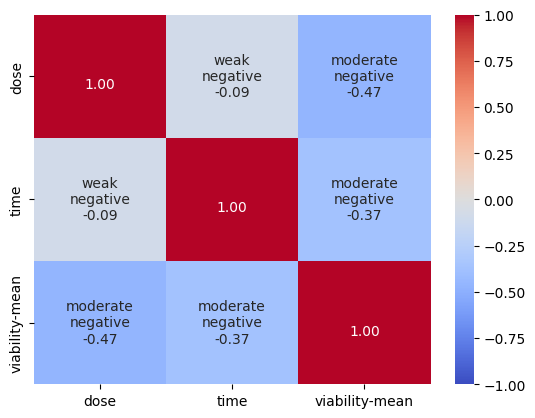

In [32]:
matrix = df.loc[:, ['dose', 'time', 'viability-mean']].corr()

text = np.array([['', 'weak\nnegative', 'moderate\nnegative'],
 ['weak\nnegative', '', 'moderate\nnegative'],
 ['moderate\nnegative', 'moderate\nnegative', '']])

matrix_arr = np.array(matrix)

formatted_text = (np.asarray(["{0}\n{1:.2f}".format(text, matrix) for text, matrix
                                in zip(text.flatten(), matrix_arr.flatten())])).reshape(3, 3)

sns.heatmap(matrix, annot=formatted_text, fmt="", vmin=-1, vmax=1, cmap="coolwarm")

Text(0.5, 1.0, 'All Flavonoids')

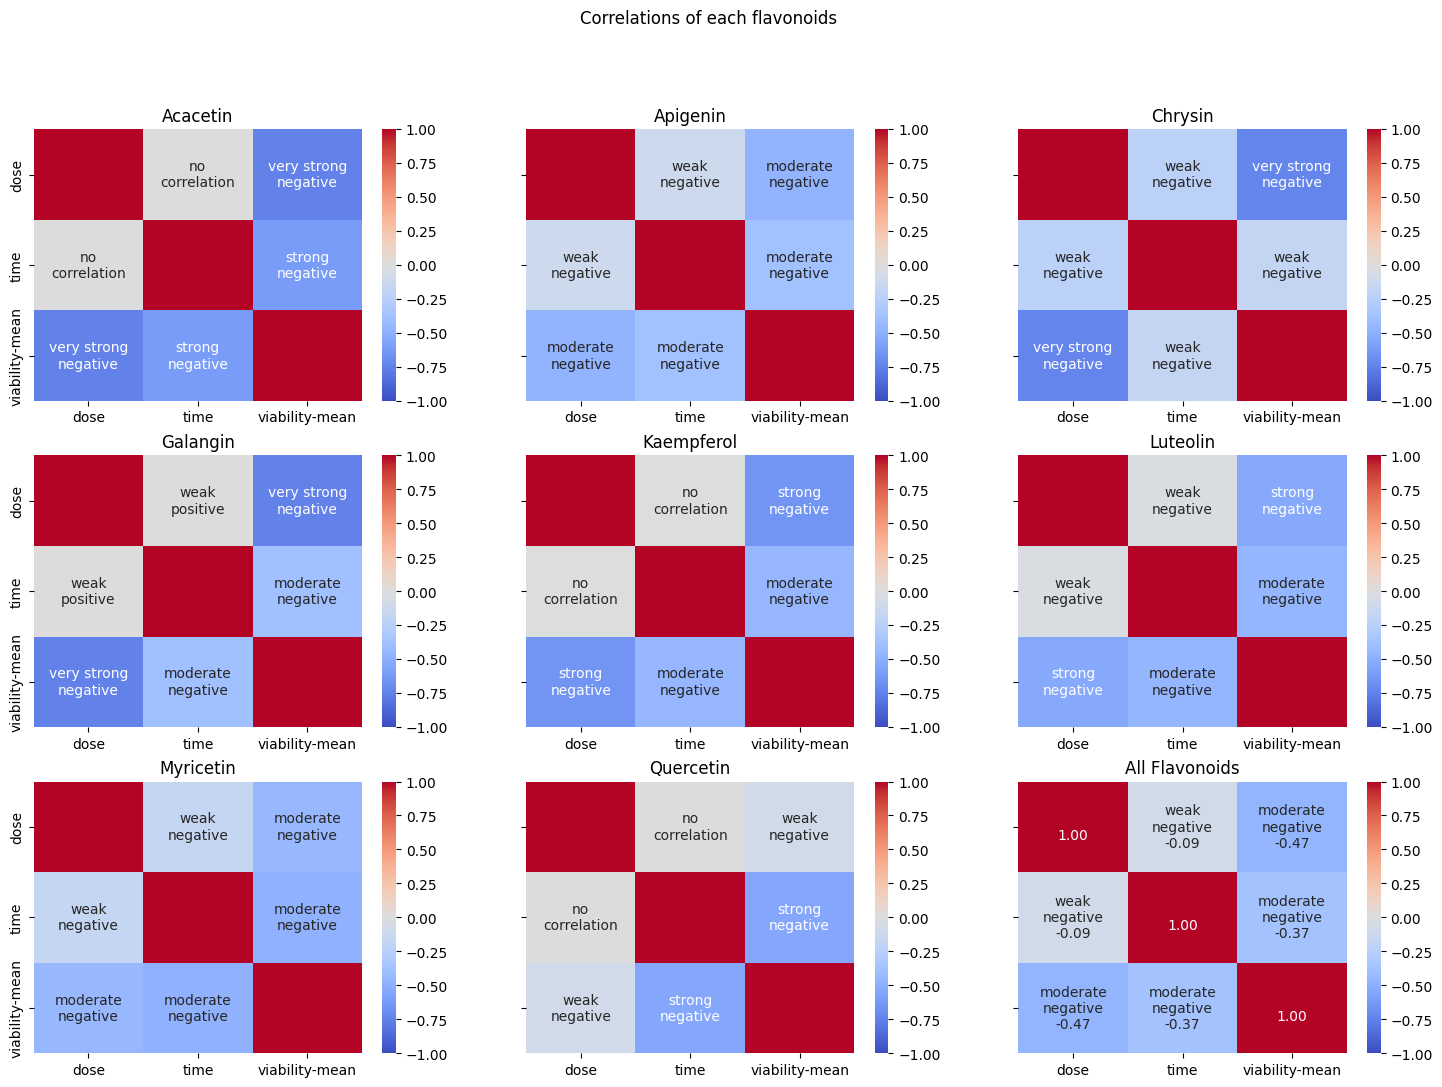

In [33]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharey=True)
fig.suptitle('Correlations of each flavonoids')

sns.heatmap(matrix11, annot=text11, fmt="", vmin=-1, vmax=1, cmap="coolwarm", ax=axes[0, 0])
axes[0, 0].set_title('Acacetin')

sns.heatmap(matrix12, annot=text12, fmt="", vmin=-1, vmax=1, cmap="coolwarm", ax=axes[0, 1])
axes[0, 1].set_title('Apigenin')

sns.heatmap(matrix13, annot=text13, fmt="", vmin=-1, vmax=1, cmap="coolwarm", ax=axes[0, 2])
axes[0, 2].set_title('Chrysin')

sns.heatmap(matrix21, annot=text21, fmt="", vmin=-1, vmax=1, cmap="coolwarm", ax=axes[1, 0])
axes[1, 0].set_title('Galangin')

sns.heatmap(matrix22, annot=text22, fmt="", vmin=-1, vmax=1, cmap="coolwarm", ax=axes[1, 1])
axes[1, 1].set_title('Kaempferol')

sns.heatmap(matrix23, annot=text23, fmt="", vmin=-1, vmax=1, cmap="coolwarm", ax=axes[1, 2])
axes[1, 2].set_title('Luteolin')

sns.heatmap(matrix31, annot=text31, fmt="", vmin=-1, vmax=1, cmap="coolwarm", ax=axes[2, 0])
axes[2, 0].set_title('Myricetin')

sns.heatmap(matrix32, annot=text32, fmt="", vmin=-1, vmax=1, cmap="coolwarm", ax=axes[2, 1])
axes[2, 1].set_title('Quercetin')

sns.heatmap(matrix, annot=formatted_text, fmt="", vmin=-1, vmax=1, cmap="coolwarm", ax=axes[2, 2])
axes[2, 2].set_title('All Flavonoids')
